In [ ]:
from natsort import natsorted
import numpy as np
import seaborn as sns
import pandas as pd

import matplotlib.pyplot as plt
import os

import torch
import torch.nn as nn
import torch.nn.functional as F
import scipy as sp
import scipy.signal as signal
import torchaudio
import math
from sklearn import svm

import torchvision
import torchvision.transforms as transforms
import torchaudio.models as audio_models

from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset

import time

!pip install networkx
import networkx as nx

In [ ]:
lib_dir = '/content/drive/MyDrive/Project/BrainRegionId/Project44/Code'
os.chdir(lib_dir)
print('library directory: ' + lib_dir)
from modules.data import *

library directory: /content/drive/MyDrive/Project/BrainRegionId/Project44/Code


In [ ]:
dict_dir = '/content/drive/MyDrive/Project/BrainRegionId/Project37/Data/dat'
acronym_list = acronym_list_gen(dict_dir)

In [ ]:
community_dict_stim = torch.load('/content/drive/MyDrive/Project/BrainRegionId/Science/results/communities/StimOn/community_stimOn_dict.pt', weights_only=False)
Mat_dict_stim = torch.load('/content/drive/MyDrive/Project/BrainRegionId/Science/results/communities/Confusion_mat_stimOn_times.pt', weights_only=False)

In [ ]:
community_dict_rest = torch.load('/content/drive/MyDrive/Project/BrainRegionId/Science/results/communities/community_dict.pt', weights_only=False)
Mat_dict_rest = torch.load('/content/drive/MyDrive/Project/BrainRegionId/Project44/Result/Confusion_mat.pt', weights_only=False)

In [ ]:
Mat_dict_stim_repeat = torch.load('/content/drive/MyDrive/Project/BrainRegionId/Science/results/communities/repeat/Confusion_mat_stimOn_times_repeat.pt', weights_only=False)
Mat_dict_rest_repeat = torch.load('/content/drive/MyDrive/Project/BrainRegionId/Science/results/communities/repeat/Confusion_mat_stimOff_times_repeat.pt', weights_only=False)

Mat_dict_stim_512_repeat = torch.load('/content/drive/MyDrive/Project/BrainRegionId/Science/results/communities/repeat/Confusion_mat_stimOn_times_512_repeat.pt', weights_only=False)
Mat_dict_rest_512_repeat = torch.load('/content/drive/MyDrive/Project/BrainRegionId/Science/results/communities/repeat/Confusion_mat_stimOff_times_512_repeat.pt', weights_only=False)

In [ ]:
ba_selec = ['MRN', 'VISp5', 'CP', 'VISam']

In [ ]:
ratio_dict = torch.load('/content/drive/MyDrive/Project/BrainRegionId/Science/results/communities/repeat/ratio_dict_stimOff_times.pt', weights_only=False)

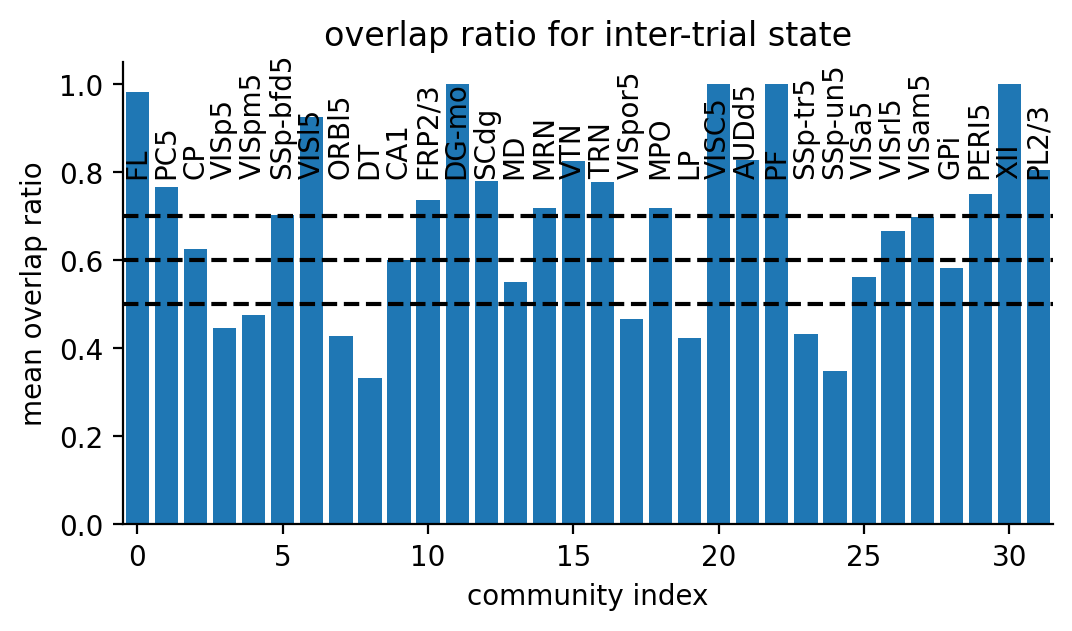

In [ ]:
plt.figure(figsize=(6, 3), dpi=200)
plt.bar(ratio_dict['label_id'], ratio_dict['ratio'])
plt.plot([-0.5, 31.5], [0.6, 0.6], 'k--')
plt.plot([-0.5, 31.5], [0.7, 0.7], 'k--')
plt.plot([-0.5, 31.5], [0.5, 0.5], 'k--')
plt.xlabel('community index')
plt.ylabel('mean overlap ratio')
plt.title('overlap ratio for inter-trial state')
plt.xlim([-0.5, 31.5])
for acronym_mark in ['FL', 'PC5', 'VISpm5', 'SSp-bfd5', 'VISl5', 'ORBl5', 'DT',
                     'SCdg', 'MD', 'VTN', 'VISpor5', 'VISC5', 'MPO', 'MRN', 'LP',
                     'CP', 'VISp5', 'DG-mo', 'CA1', 'FRP2/3', 'AUDd5', 'TRN', 'PF', 'SSp-tr5', 'SSp-un5', 'VISa5', 'VISrl5', 'PL2/3', 'XII', 'PERI5', 'VISam5', 'GPi']:
    try:
        pos = community_dict_rest[1.0]['communities_label'][np.argwhere(community_dict_rest[1.0]['communities_acronym'] == acronym_mark).flatten()]
        plt.text(pos-0.5, 0.8, acronym_mark, rotation=90)
    except:
        continue
sns.despine()
plt.show()

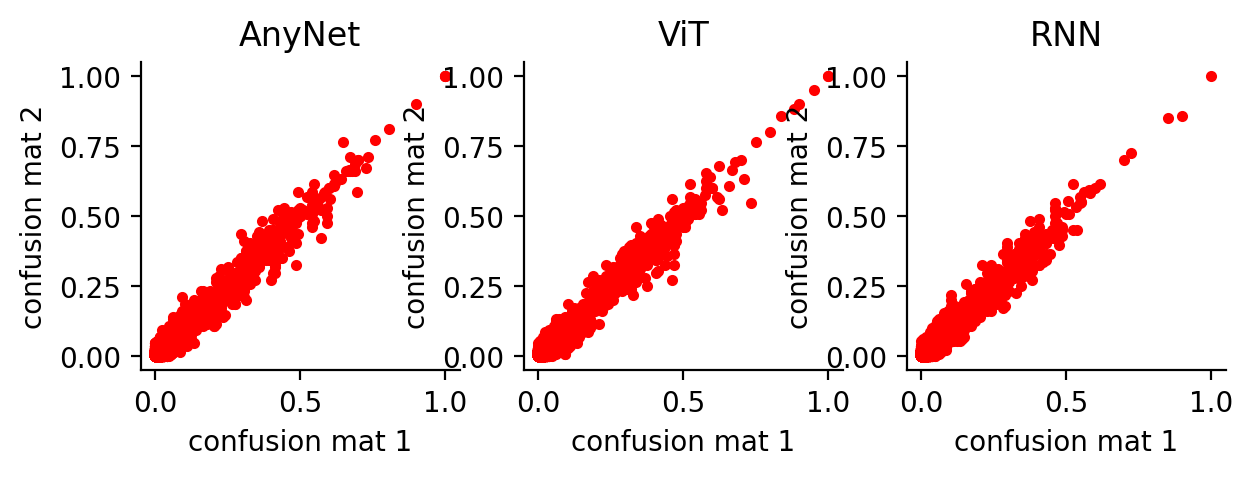

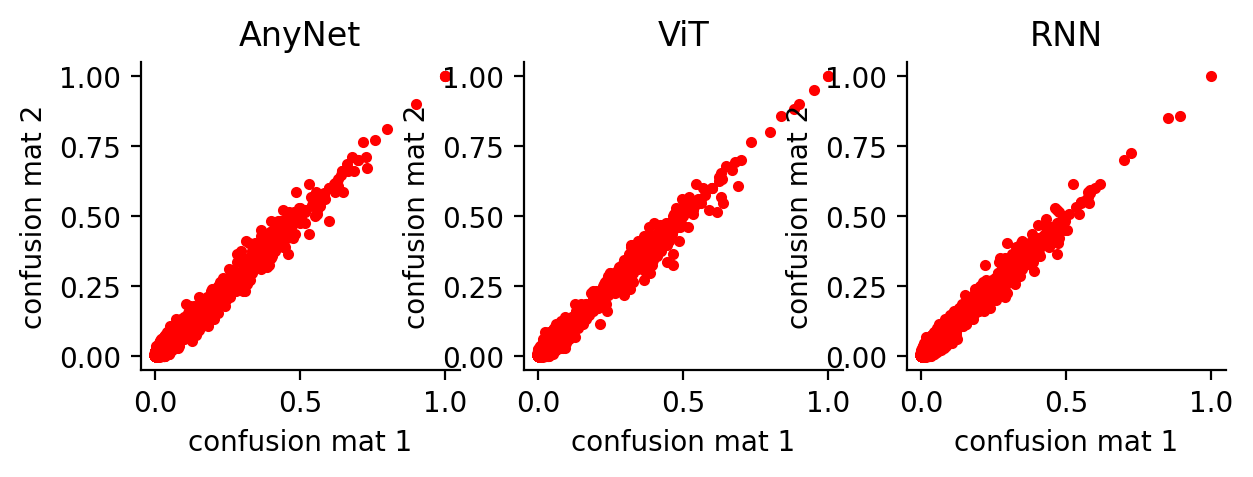

In [ ]:
plt.figure(figsize=(7, 2), dpi=200)
for ii, classifier_name in enumerate(['AnyNet', 'ViT', 'RNN']):
    plt.subplot(1, 3, ii + 1)
    plt.plot(Mat_dict_rest_repeat[0][classifier_name], Mat_dict_rest[classifier_name], 'r.')
    plt.title(classifier_name)
    plt.xlabel('confusion mat 1')
    plt.ylabel('confusion mat 2')


sns.despine()
plt.show()

plt.figure(figsize=(7, 2), dpi=200)
for ii, classifier_name in enumerate(['AnyNet', 'ViT', 'RNN']):
    plt.subplot(1, 3, ii + 1)
    plt.plot(Mat_dict_rest_512_repeat[0][classifier_name], Mat_dict_rest[classifier_name], 'r.')
    plt.title(classifier_name)
    plt.xlabel('confusion mat 1')
    plt.ylabel('confusion mat 2')


sns.despine()
plt.show()

In [ ]:
pos

array([14])

In [ ]:
pos

array([], dtype=int64)

In [ ]:
community_dict_rest[1.0]['communities_label'][np.argwhere(community_dict_rest[1.0]['communities_acronym'] == 'LP').flatten()]



array([19])

In [ ]:
for label_ind, _ in enumerate(community_dict_rest[1.0]['communities_label']):
    print(f"brain area: {community_dict_rest[1.0]['communities_acronym'][label_ind]}, community index: {community_dict_rest[1.0]['communities_label'][label_ind]}")


brain area: KF, community index: 0
brain area: I5, community index: 0
brain area: DCO, community index: 0
brain area: VCO, community index: 0
brain area: CU, community index: 0
brain area: ECU, community index: 0
brain area: SPVC, community index: 0
brain area: SPVI, community index: 0
brain area: Pa5, community index: 0
brain area: AMBv, community index: 0
brain area: GRN, community index: 0
brain area: ICB, community index: 0
brain area: IO, community index: 0
brain area: IRN, community index: 0
brain area: LIN, community index: 0
brain area: LRNm, community index: 0
brain area: MARN, community index: 0
brain area: MDRNd, community index: 0
brain area: MDRNv, community index: 0
brain area: PARN, community index: 0
brain area: PAS, community index: 0
brain area: PGRNd, community index: 0
brain area: PGRNl, community index: 0
brain area: PRP, community index: 0
brain area: LAV, community index: 0
brain area: MV, community index: 0
brain area: SPIV, community index: 0
brain area: x, com

In [ ]:
import copy

def modularity_separation(M, resolution, sort=True):
    G = nx.from_numpy_array(M)
    c = nx.community.greedy_modularity_communities(G, weight='weight', resolution=resolution)
    acronym_label = []
    community_label = []
    index = []
    for c_ii, c0 in enumerate(c):
        for c_index in c0:
            community_label.append(c_ii)
            acronym_label.append(acronym_list[c_index])
            index.append(c_index)

    community_label = np.array(community_label)
    acronym_label = np.array(acronym_label)
    index = np.array(index)

    if sort == True:
        sort_index = np.argsort(index)
        community_label = community_label[sort_index]
        acronym_label = acronym_label[sort_index]
        index = index[sort_index]

    return community_label, acronym_label, index

In [ ]:
np.unique(community_dict_rest[1.0]['communities_label'])

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31])

In [ ]:
np.argwhere(community_dict_rest[1.0]['communities_acronym'] == )

array([[0]])

In [ ]:
resolution = 1.0

ratio_dict = {}
ratio_list = []
label_list = []
for label_id in np.unique(community_dict_rest[1.0]['communities_label']):

    br_center = community_dict_rest[1.0]['communities_acronym'][np.argwhere(community_dict_rest[1.0]['communities_label'] == label_id).flatten()[0]]
    overlap_ratio = []
    for rep in range(0, 10):
        try:

            label_selec = community_dict_rest[1.0]['communities_label'][np.argwhere(community_dict_rest[1.0]['communities_acronym'] == br_center).flatten()]
            acronym_selec = community_dict_rest[1.0]['communities_acronym'][np.argwhere(community_dict_rest[1.0]['communities_label'] == label_selec).flatten()]
            acronym_id_selec = community_dict_rest[1.0]['communities'][np.argwhere(community_dict_rest[1.0]['communities_label'] == label_selec).flatten()]

            community_number = []
            community_index = {}
            community_dat_ho = {}
            for name in ['AnyNet', 'ViT', 'RNN']:

                X = copy.deepcopy(Mat_dict_rest_repeat[rep][name])
                community_label, acronym_label, index = modularity_separation(X, resolution)

                community_number.append(len(np.unique(community_label)))
                community_index[name] = community_label

            communities = []
            communities_label = []
            communities_acronym = []
            ii = 0
            for community_ii_AnyNet in range(0, community_number[0]):
                for community_ii_ViT in range(0, community_number[1]):
                    for community_ii_RNN in range(0, community_number[2]):
                        community0 = np.intersect1d(np.intersect1d(np.argwhere(community_index['AnyNet'] == community_ii_AnyNet).flatten(),
                                                        np.argwhere(community_index['ViT'] == community_ii_ViT).flatten()),
                                        np.argwhere(community_index['RNN'] == community_ii_RNN).flatten())
                        if len(community0) > 2:
                            communities.append(community0)
                            communities_acronym.append(np.array(acronym_list)[community0])
                            communities_label.append(ii * np.ones_like(community0))
                            ii = ii + 1

            communities = np.concat(communities)
            communities_label = np.concat(communities_label)
            communities_acronym = np.concat(communities_acronym)

            community_dat_ho['communities'] = communities
            community_dat_ho['communities_label'] = communities_label
            community_dat_ho['communities_acronym'] = communities_acronym

            label_selec_ho = community_dat_ho['communities_label'][np.argwhere(community_dat_ho['communities_acronym'] == br_center).flatten()]
            acronym_selec_ho = community_dat_ho['communities_acronym'][np.argwhere(community_dat_ho['communities_label'] == label_selec_ho).flatten()]

        except:
            continue

        overlap_ratio.append(len(np.intersect1d(acronym_selec_ho, acronym_selec)) / len(acronym_selec))

    overlap_ratio = np.array(overlap_ratio)
    ratio_list.append(overlap_ratio.mean())
    label_list.append(label_id)
    print(label_id)

ratio_dict['ratio'] = np.array(ratio_list)
ratio_dict['label_id'] = np.array(label_list)


# torch.save(ratio_dict, '/content/drive/MyDrive/Project/BrainRegionId/Science/results/communities/repeat/ratio_dict_stimOff_times.pt')

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31


In [ ]:
resolution = 1.0

ratio_dict = {}
ratio_list = []
label_list = []
for label_id in np.unique(community_dict_rest[1.0]['communities_label']):

    br_center = community_dict_rest[1.0]['communities_acronym'][np.argwhere(community_dict_rest[1.0]['communities_label'] == label_id).flatten()[0]]
    overlap_ratio = []
    for rep in range(0, 5):
        try:

            label_selec = community_dict_rest[1.0]['communities_label'][np.argwhere(community_dict_rest[1.0]['communities_acronym'] == br_center).flatten()]
            acronym_selec = community_dict_rest[1.0]['communities_acronym'][np.argwhere(community_dict_rest[1.0]['communities_label'] == label_selec).flatten()]
            acronym_id_selec = community_dict_rest[1.0]['communities'][np.argwhere(community_dict_rest[1.0]['communities_label'] == label_selec).flatten()]

            community_number = []
            community_index = {}
            community_dat_ho = {}
            for name in ['AnyNet', 'ViT', 'RNN']:

                X = copy.deepcopy(Mat_dict_rest_512_repeat[rep][name])
                community_label, acronym_label, index = modularity_separation(X, resolution)

                community_number.append(len(np.unique(community_label)))
                community_index[name] = community_label

            communities = []
            communities_label = []
            communities_acronym = []
            ii = 0
            for community_ii_AnyNet in range(0, community_number[0]):
                for community_ii_ViT in range(0, community_number[1]):
                    for community_ii_RNN in range(0, community_number[2]):
                        community0 = np.intersect1d(np.intersect1d(np.argwhere(community_index['AnyNet'] == community_ii_AnyNet).flatten(),
                                                        np.argwhere(community_index['ViT'] == community_ii_ViT).flatten()),
                                        np.argwhere(community_index['RNN'] == community_ii_RNN).flatten())
                        if len(community0) > 2:
                            communities.append(community0)
                            communities_acronym.append(np.array(acronym_list)[community0])
                            communities_label.append(ii * np.ones_like(community0))
                            ii = ii + 1

            communities = np.concat(communities)
            communities_label = np.concat(communities_label)
            communities_acronym = np.concat(communities_acronym)

            community_dat_ho['communities'] = communities
            community_dat_ho['communities_label'] = communities_label
            community_dat_ho['communities_acronym'] = communities_acronym

            label_selec_ho = community_dat_ho['communities_label'][np.argwhere(community_dat_ho['communities_acronym'] == br_center).flatten()]
            acronym_selec_ho = community_dat_ho['communities_acronym'][np.argwhere(community_dat_ho['communities_label'] == label_selec_ho).flatten()]

        except:
            continue

        overlap_ratio.append(len(np.intersect1d(acronym_selec_ho, acronym_selec)) / len(acronym_selec))

    overlap_ratio = np.array(overlap_ratio)
    ratio_list.append(overlap_ratio.mean())
    label_list.append(label_id)
    print(label_id)

ratio_dict['ratio'] = np.array(ratio_list)
ratio_dict['label_id'] = np.array(label_list)

# torch.save(ratio_dict, '/content/drive/MyDrive/Project/BrainRegionId/Science/results/communities/repeat/ratio_dict_stimOff_times_512.pt')

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31


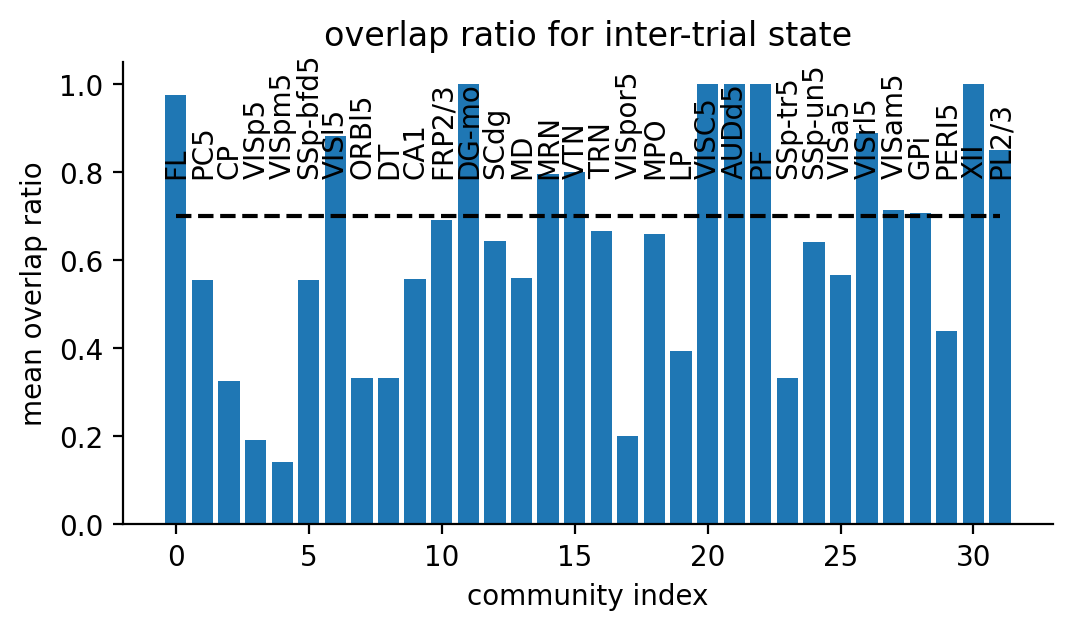

In [85]:
plt.figure(figsize=(6, 3), dpi=200)
plt.bar(ratio_dict['label_id'], ratio_dict['ratio'])
plt.plot([0, 31], [0.7, 0.7], 'k--')
plt.xlabel('community index')
plt.ylabel('mean overlap ratio')
plt.title('overlap ratio for inter-trial state')
sns.despine()
for acronym_mark in ['FL', 'PC5', 'VISpm5', 'SSp-bfd5', 'VISl5', 'ORBl5', 'DT',
                     'SCdg', 'MD', 'VTN', 'VISpor5', 'VISC5', 'MPO', 'MRN', 'LP',
                     'CP', 'VISp5', 'DG-mo', 'CA1', 'FRP2/3', 'AUDd5', 'TRN', 'PF', 'SSp-tr5', 'SSp-un5', 'VISa5', 'VISrl5', 'PL2/3', 'XII', 'PERI5', 'VISam5', 'GPi']:
    try:
        pos = community_dict_rest[1.0]['communities_label'][np.argwhere(community_dict_rest[1.0]['communities_acronym'] == acronym_mark).flatten()]
        plt.text(pos-0.5, 0.8, acronym_mark, rotation=90)
    except:
        continue
plt.show()

In [ ]:
acronym_selec_ho

NameError: name 'acronym_selec_ho' is not defined

In [ ]:
ratio_dict

{'ratio': array([0.98235294, 0.76666667, 0.6255814 , 0.44705882, 0.47619048,
        0.7037037 , 0.925     , 0.42857143, 0.33333333, 0.6       ,
        0.73636364, 1.        , 0.78148148, 0.55      , 0.71969697,
        0.825     , 0.77777778, 0.46666667, 0.72      , 0.42424242,
        1.        , 0.82857143, 1.        , 0.43333333, 0.34920635,
        0.5625    , 0.66666667, 0.6984127 , 0.58333333, 0.75      ,
        1.        , 0.80555556]),
 'label_id': array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31])}

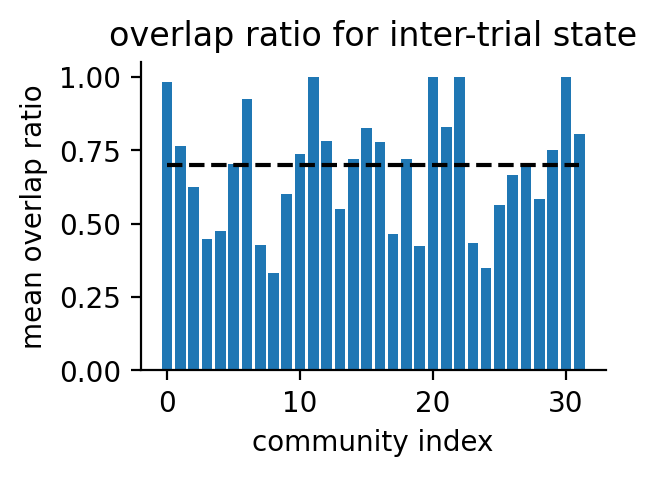

In [ ]:
plt.figure(figsize=(3, 2), dpi=200)
plt.bar(ratio_dict['label_id'], ratio_dict['ratio'])
plt.plot([0, 31], [0.7, 0.7], 'k--')
plt.xlabel('community index')
plt.ylabel('mean overlap ratio')
plt.title('overlap ratio for inter-trial state')
sns.despine()
plt.show()

In [ ]:
overlap_ratio = np.array(overlap_ratio)
print(overlap_ratio.mean())

0.8136363636363635


In [ ]:
communities_label

array([ 0,  0,  0,  1,  1,  1,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
        2,  2,  2,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  4,
        4,  4,  4,  5,  5,  5,  5,  5,  5,  5,  5,  6,  6,  6,  6,  6,  6,
        7,  7,  7,  7,  8,  8,  8,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9,
        9,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9,
        9,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9,
        9,  9,  9,  9,  9,  9,  9,  9, 10, 10, 10, 11, 11, 11, 11, 11, 11,
       11, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12,
       12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12,
       12, 12, 12, 12, 12, 12, 12, 12, 12, 13, 13, 13, 14, 14, 14, 15, 15,
       15, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16,
       16, 16, 16, 16, 16, 16, 16, 16, 17, 17, 17, 17, 18, 18, 18, 18, 18,
       18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 19, 19, 19,
       19, 19, 19, 19, 19

In [ ]:
communities_acronym

array(['SSp-ul5', 'ACAv1', 'IG', 'VISp4', 'RSPagl1', 'VISa1', 'SSp-bfd1',
       'SSp-bfd2/3', 'SSs2/3', 'SSs4', 'VISl1', 'VISl2/3', 'VISl4',
       'VISl5', 'VISp2/3', 'VISpl1', 'VISli2/3', 'VISli5', 'TEa2/3',
       'TEa4', 'SSp-ll1', 'SSp-ll2/3', 'SSp-ll4', 'SSp-tr1', 'VISp1',
       'VISp5', 'VISp6a', 'RSPagl2/3', 'RSPagl5', 'RSPagl6a', 'RSPd6a',
       'APr', 'POST', 'SSp-ul2/3', 'SSp-ul4', 'VISpl5', 'VISpl6a',
       'SSp-ul1', 'RSPd2/3', 'RSPd5', 'RSPv1', 'RSPv2/3', 'SCop', 'SCsg',
       'SCzo', 'VISam1', 'VISpm1', 'VISpm2/3', 'VISpm4', 'VISpm5',
       'VISa2/3', 'SSp-bfd4', 'SSp-bfd5', 'SSp-bfd6a', 'SSp-bfd6b',
       'SSp-tr2/3', 'SSp-tr4', 'SSp-tr5', 'KF', 'I5', 'DCO', 'VCO', 'CU',
       'ECU', 'SPVC', 'SPVI', 'Pa5', 'AMBv', 'DMX', 'GRN', 'ICB', 'IO',
       'IRN', 'LIN', 'LRNm', 'MARN', 'MDRNd', 'MDRNv', 'PARN', 'PAS',
       'PGRNd', 'PGRNl', 'PRP', 'LAV', 'MV', 'SPIV', 'x', 'y', 'FN', 'IP',
       'DN', 'VeCB', 'NTS', 'SPVO', 'LING', 'CENT2', 'CENT3', 'CUL4 5',
       '

In [ ]:
label_selec = community_dict_rest[1.0]['communities_label'][np.argwhere(community_dict_rest[1.0]['communities_acronym'] == 'VISp5').flatten()]
acronym_selec = community_dict_rest[1.0]['communities_acronym'][np.argwhere(community_dict_rest[1.0]['communities_label'] == label_selec).flatten()]
acronym_id_selec = community_dict_rest[1.0]['communities'][np.argwhere(community_dict_rest[1.0]['communities_label'] == label_selec).flatten()]


In [ ]:
acronym_id_selec

array([ 99, 100, 101, 102, 103, 108, 109, 116, 170, 171, 175, 176, 178,
       225, 319, 320, 321])

In [ ]:
'PPT' in acronym_list

True

In [ ]:
np.random.choice(acronym_id_selec)

np.int64(178)

In [ ]:
['MRN', 'III', 'NOT', 'PPT', 'VISp5', 'CP']

In [ ]:
resolution = 1.0
Mat_dict = Mat_dict_rest

br_pertub_overlap = {}
for br_center in ['III']:

    label_selec = community_dict_rest[1.0]['communities_label'][np.argwhere(community_dict_rest[1.0]['communities_acronym'] == br_center).flatten()]
    acronym_selec = community_dict_rest[1.0]['communities_acronym'][np.argwhere(community_dict_rest[1.0]['communities_label'] == label_selec).flatten()]
    acronym_id_selec = community_dict_rest[1.0]['communities'][np.argwhere(community_dict_rest[1.0]['communities_label'] == label_selec).flatten()]

    rep_num = 10
    node_choice = np.random.choice(np.setdiff1d(np.array([id for id, _ in enumerate(acronym_list)]), acronym_id_selec), rep_num, replace=False)

    overlap_list = []
    for ii in range(0, rep_num):
        node_ii = node_choice[ii]
        while True:
            community_number = []
            community_index = {}
            community_dat_ho = {}
            for name in ['AnyNet', 'ViT', 'RNN']:

                X1 = np.delete(copy.deepcopy(Mat_dict[name]), node_ii, axis=0)
                X1 = np.delete(X1, node_ii, axis=1)
                community_label, acronym_label, index = modularity_separation(X1, resolution)

                # X = copy.deepcopy(Mat_dict[name])
                # community_label, acronym_label, index = modularity_separation(X, resolution)

                community_number.append(len(np.unique(community_label)))
                community_index[name] = community_label

            communities = []
            communities_label = []
            communities_acronym = []
            ii = 0
            for community_ii_AnyNet in range(0, community_number[0]):
                for community_ii_ViT in range(0, community_number[1]):
                    for community_ii_RNN in range(0, community_number[2]):
                        community0 = np.intersect1d(np.intersect1d(np.argwhere(community_index['AnyNet'] == community_ii_AnyNet).flatten(),
                                                        np.argwhere(community_index['ViT'] == community_ii_ViT).flatten()),
                                        np.argwhere(community_index['RNN'] == community_ii_RNN).flatten())
                        if len(community0) > 2:
                            communities.append(community0)
                            communities_acronym.append(np.array(acronym_list)[community0])
                            communities_label.append(ii * np.ones_like(community0))
                            ii = ii + 1

            communities = np.concat(communities)
            communities_label = np.concat(communities_label)
            communities_acronym = np.concat(communities_acronym)
            community_dat_ho['communities'] = communities
            community_dat_ho['communities_label'] = communities_label
            community_dat_ho['communities_acronym'] = communities_acronym

            if br_center in communities_acronym:
                break

        label_selec_ho = community_dat_ho['communities_label'][np.argwhere(community_dat_ho['communities_acronym'] == br_center).flatten()]
        acronym_selec_ho = community_dat_ho['communities_acronym'][np.argwhere(community_dat_ho['communities_label'] == label_selec_ho).flatten()]

        overlap_list.append(len(np.intersect1d(acronym_selec_ho, acronym_selec)) / len(acronym_selec))


    br_pertub_overlap[br_center] = np.array(overlap_list)


# torch.save(br_pertub_overlap, '/content/drive/MyDrive/Project/BrainRegionId/Science/results/overlap/rest_overlap.pt')

KeyboardInterrupt: 

In [ ]:
br_pertub_overlap['NOT'].mean()

np.float64(0.5227272727272728)

In [ ]:
from google.colab import runtime
runtime.unassign()

In [ ]:
label_selec_ho = community_dat_ho['communities_label'][np.argwhere(community_dat_ho['communities_acronym'] == 'VISp5').flatten()]
acronym_selec_ho = community_dat_ho['communities_acronym'][np.argwhere(community_dat_ho['communities_label'] == label_selec_ho).flatten()]

In [ ]:
acronym_selec_ho

array(['VISp1', 'VISp2/3', 'VISp4', 'VISp5', 'VISp6a', 'VISpl5',
       'VISpl6a', 'VISli2/3', 'RSPagl5', 'RSPagl6a', 'RSPv1', 'VISa1',
       'SCsg'], dtype='<U10')

In [ ]:
acronym_selec

array(['VISp1', 'VISp2/3', 'VISp4', 'VISp5', 'VISp6a', 'VISpl5',
       'VISpl6a', 'VISli2/3', 'RSPagl5', 'RSPagl6a', 'RSPd5', 'RSPd6a',
       'RSPv1', 'APr', 'SCop', 'SCsg', 'SCzo'], dtype='<U10')

In [ ]:
len(np.intersect1d(acronym_selec_ho, acronym_selec)) / len(acronym_selec)

0.7058823529411765

In [ ]:
import copy

In [ ]:
st_dict = {}
classifier = 'AnyNet'
resolution = 1.0

labels = community_dict_rest[resolution]['communities_label']
acronym_id = community_dict_rest[resolution]['communities']
acronym_name = community_dict_rest[resolution]['communities_acronym']
Mat_rest = Mat_dict_rest[classifier]

Mat_stim = Mat_dict_stim[classifier]

modularity_list_rest = []
modularity_list_stim = []

for label in np.unique(labels):
    ind = np.argwhere(labels == label).flatten()
    rm_ind = np.setdiff1d(np.array([ii for ii in range(0, len(acronym_list))]), ind)
    X1 = np.delete(copy.deepcopy(Mat_rest), rm_ind, axis=0)
    X1 = np.delete(X1, rm_ind, axis=1)

    X2 = np.delete(copy.deepcopy(Mat_stim), rm_ind, axis=0)
    X2 = np.delete(X2, rm_ind, axis=1)

    G_ii = nx.from_numpy_array(X1)
    G_ii_stim = nx.from_numpy_array(X2)
    c_ii = nx.community.greedy_modularity_communities(G_ii, weight='weight', resolution=resolution)
    modularity_list_rest.append(nx.community.modularity(G_ii, c_ii))
    modularity_list_stim.append(nx.community.modularity(G_ii_stim, c_ii))
modularity_list_rest = np.array(modularity_list_rest)
modularity_list_stim = np.array(modularity_list_stim)


modularity_rest_rec = []
modularity_stim_rec = []
acronym_rec = []
group_rec = []
for id, acronym in enumerate(acronym_list):
    if 'VIS' in acronym:
        rec = True
        group = 'VC'

    elif 'Apr' in acronym:
        rec = True
        group = 'VC'

    elif 'RSPag' in acronym:
        rec = True
        group = 'VC'

    elif 'SC' in acronym:
        rec = True
        group = 'VS'

    elif 'II' in acronym:
        rec = True
        group = 'VS'

    elif 'LG' in acronym:
        rec = True
        group = 'VS'

    elif acronym in ['IGL', 'LP', 'RT']:
        rec = True
        group = 'VS'

    elif 'SC' in acronym:
        rec = True
        group = 'M'

    elif acronym in ['SGN', 'III', 'NOT', 'MPT', 'Su3', 'OP', 'NPC', 'INC', 'PPT', 'MA3', 'IV', 'VI', 'EW']:
        rec = True
        group = 'M'

    else:
        rec = False
        group = 'M'

    if rec:
        if acronym in acronym_name:
            modularity_rest_rec.append(modularity_list_rest[labels[np.argwhere(acronym_id == id).flatten()]])
            modularity_stim_rec.append(modularity_list_stim[labels[np.argwhere(acronym_id == id).flatten()]])
            acronym_rec.append(acronym_name[np.argwhere(acronym_id == id).flatten()])
            group_rec.append(group)

modularity_rest_rec = np.array(modularity_rest_rec)
modularity_stim_rec = np.array(modularity_stim_rec)
acronym_rec = np.array(acronym_rec)
group_rec = np.array(group_rec)


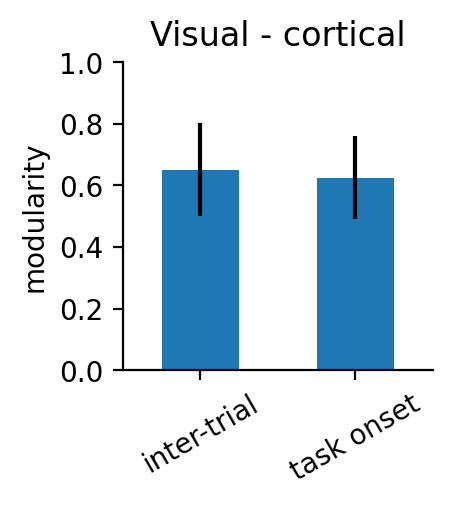

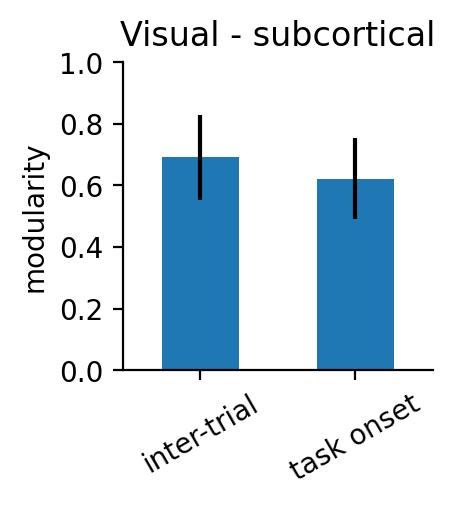

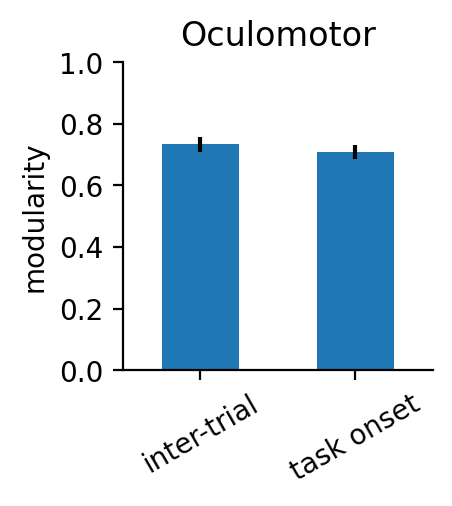

In [ ]:
group_name = 'VC'
plt.figure(figsize=(2, 2), dpi=200)
plt.bar([1, 2],
    [modularity_rest_rec[np.argwhere(group_rec == group_name).flatten()].mean(), modularity_stim_rec[np.argwhere(group_rec == group_name).flatten()].mean()],
        yerr=[modularity_rest_rec[np.argwhere(group_rec == group_name).flatten()].std(), modularity_stim_rec[np.argwhere(group_rec == group_name).flatten()].std()],
            width=0.5)
plt.xlim([0.5, 2.5])
plt.ylim([0.0, 1.0])
plt.xticks([1, 2], ['inter-trial', 'task onset'], rotation=30)
plt.title("Visual - cortical")
plt.ylabel('modularity')
sns.despine()
plt.show()

group_name = 'VS'
plt.figure(figsize=(2, 2), dpi=200)
plt.bar([1, 2],
    [modularity_rest_rec[np.argwhere(group_rec == group_name).flatten()].mean(), modularity_stim_rec[np.argwhere(group_rec == group_name).flatten()].mean()],
        yerr=[modularity_rest_rec[np.argwhere(group_rec == group_name).flatten()].std(), modularity_stim_rec[np.argwhere(group_rec == group_name).flatten()].std()],
            width=0.5)
plt.xlim([0.5, 2.5])
plt.ylim([0.0, 1.0])
plt.xticks([1, 2], ['inter-trial', 'task onset'], rotation=30)
plt.title("Visual - subcortical")
plt.ylabel('modularity')
sns.despine()
plt.show()

group_name = 'M'
plt.figure(figsize=(2, 2), dpi=200)
plt.bar([1, 2],
    [modularity_rest_rec[np.argwhere(group_rec == group_name).flatten()].mean(), modularity_stim_rec[np.argwhere(group_rec == group_name).flatten()].mean()],
        yerr=[modularity_rest_rec[np.argwhere(group_rec == group_name).flatten()].std(), modularity_stim_rec[np.argwhere(group_rec == group_name).flatten()].std()],
            width=0.5)
plt.xlim([0.5, 2.5])
plt.ylim([0.0, 1.0])
plt.xticks([1, 2], ['inter-trial', 'task onset'], rotation=30)
plt.ylabel('modularity')
plt.title("Oculomotor")
sns.despine()
plt.show()

In [ ]:
st_dict = {}
classifier = 'AnyNet'
resolution = 1.0
for state in ['stim', 'rest']:
    if state == 'stim':

        labels = community_dict_stim[resolution]['communities_label']
        acronym_id = community_dict_stim[resolution]['communities']
        acronym_name = community_dict_stim[resolution]['communities_acronym']
        Mat = Mat_dict_stim[classifier]

    elif state == 'rest':

        labels = community_dict_rest[resolution]['communities_label']
        acronym_id = community_dict_rest[resolution]['communities']
        acronym_name = community_dict_rest[resolution]['communities_acronym']
        Mat = Mat_dict_rest[classifier]


    modularity_list = []
    for label in np.unique(labels):
        ind = np.argwhere(labels == label).flatten()
        rm_ind = np.setdiff1d(np.array([ii for ii in range(0, len(acronym_list))]), ind)
        X1 = np.delete(copy.deepcopy(Mat), rm_ind, axis=0)
        X1 = np.delete(X1, rm_ind, axis=1)
        G_ii = nx.from_numpy_array(X1)
        c_ii = nx.community.greedy_modularity_communities(G_ii, weight='weight', resolution=resolution)
        modularity_list.append(nx.community.modularity(G_ii, c_ii))
    modularity_list = np.array(modularity_list)

    modularity_rec = []
    acronym_rec = []
    group_rec = []
    for id, acronym in enumerate(acronym_list):
        if 'VIS' in acronym:
            rec = True
            group = 'VC'

        elif 'Apr' in acronym:
            rec = True
            group = 'VC'

        elif 'RSPag' in acronym:
            rec = True
            group = 'VC'

        elif 'SC' in acronym:
            rec = True
            group = 'VS'

        elif 'II' in acronym:
            rec = True
            group = 'VS'

        elif 'LG' in acronym:
            rec = True
            group = 'VS'

        elif acronym in ['IGL', 'LP', 'RT']:
            rec = True
            group = 'VS'

        elif 'SC' in acronym:
            rec = True
            group = 'M'

        elif acronym in ['SGN', 'III', 'NOT', 'MPT', 'Su3', 'OP', 'NPC', 'INC', 'PPT', 'MA3', 'IV', 'VI', 'EW']:
            rec = True
            group = 'M'

        else:
            rec = False
            group = 'M'

        if rec:
            if acronym in acronym_name:
                modularity_rec.append(modularity_list[labels[np.argwhere(acronym_id == id).flatten()]])
                acronym_rec.append(acronym_name[np.argwhere(acronym_id == id).flatten()])
                group_rec.append(group)

    m_dict = {}
    m_dict['modularity'] = np.array(modularity_rec)
    m_dict['acronym'] = np.array(acronym_rec)
    m_dict['group'] = np.array(group_rec)

    st_dict[state] = m_dict

In [ ]:
st_dict['rest']['modularity'][st_dict['rest']['group'] == 'VC'].mean()

np.float64(0.6503841918870199)

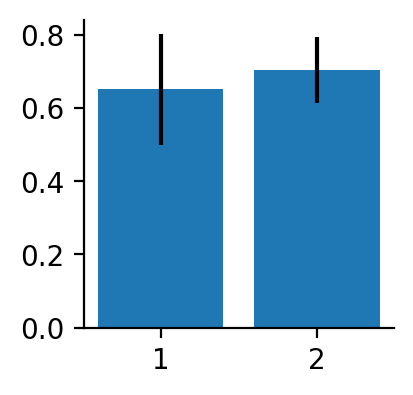

In [ ]:
plt.figure(figsize=(2, 2), dpi=200)
plt.bar([1, 2],
 [st_dict['rest']['modularity'][st_dict['rest']['group'] == 'VC'].mean(), st_dict['stim']['modularity'][st_dict['rest']['group'] == 'VC'].mean()],
        yerr=[st_dict['rest']['modularity'][st_dict['rest']['group'] == 'VC'].std(), st_dict['stim']['modularity'][st_dict['rest']['group'] == 'VC'].std()])

sns.despine()
plt.show()

In [ ]:
for acronym_id, acronym in enumerate(acronym_list):
    if 'VIS' in acronym:

    elif 'Apr' in acronym:

    elif 'RSPag' in acronym:

    elif 'SC' in acronym:

    elif 'II' in acronym:

    elif 'LG' in acronym:

    elif acronym in ['IGL', 'LP', 'RT']:

    elif 'SC' in acronym:

    elif acronym in ['SGN', 'III', 'NOT', 'MPT', 'Su3', 'OP', 'NPC', 'INC', 'PPT', 'MA3', 'IV', 'VI', 'EW']:



In [ ]:
modularity_value_stim = []
for resolution in [0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0]:
    G = nx.from_numpy_array(reverse_distance_mat.detach().cpu().numpy().copy())
    c = nx.community.greedy_modularity_communities(G, weight='weight', resolution=resolution)
    label_acronym = []
    community_label = []
    for c_ii, c0 in enumerate(c):
        for c_index in c0:
            community_label.append(c_ii)
            label_acronym.append(acronym_list[c_index])

    community_label = np.array(community_label)
    print(f'resolution: {resolution}>>>>>>>>>>>', nx.community.modularity(G, c))
    # community_label
    modularity_value_stim.append(nx.community.modularity(G, c))
modularity_value_stim = np.array(modularity_value_stim)



In [ ]:
import copy

def modularity_separation(M, resolution, sort=True):
    G = nx.from_numpy_array(M)
    c = nx.community.greedy_modularity_communities(G, weight='weight', resolution=resolution)
    acronym_label = []
    community_label = []
    index = []
    for c_ii, c0 in enumerate(c):
        for c_index in c0:
            community_label.append(c_ii)
            acronym_label.append(acronym_list[c_index])
            index.append(c_index)

    community_label = np.array(community_label)
    acronym_label = np.array(acronym_label)
    index = np.array(index)

    if sort == True:
        sort_index = np.argsort(index)
        community_label = community_label[sort_index]
        acronym_label = acronym_label[sort_index]
        index = index[sort_index]

    return community_label, acronym_label, index

In [ ]:
len(community_dict[1.0]['communities_acronym'])

338

In [ ]:
len(np.unique(community_dict[1.0]['communities_acronym']))

338